# Polynomial Regression — Capturing Non-Linear Relationships

This notebook continues from `regression_analysis.ipynb`, exploring **Polynomial Features** to capture non-linear patterns in the data.

### Why Polynomial Features?

Linear Regression assumes the relationship between features and target is a **straight line**:

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2$$

But real-world data often has **curves**. For example, the effect of house age on price might not be linear — a 5-year-old house and a 30-year-old house might lose value at different rates.

**Polynomial Features** transform the input by adding powers and interactions:

| Degree | Features generated from $[x_1, x_2]$ |
|---|---|
| 1 (Linear) | $x_1, x_2$ |
| 2 (Quadratic) | $x_1, x_2, x_1^2, x_1 x_2, x_2^2$ |
| 3 (Cubic) | All of degree 2 + $x_1^3, x_1^2 x_2, x_1 x_2^2, x_2^3$ |

This lets a Linear Regression model fit **curved surfaces** while still using the same linear math under the hood.

> ⚠️ **Warning:** Higher degree = more features = higher risk of **overfitting**, especially with small datasets like ours (50 rows).

## 1. Setup & Load Data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style='whitegrid')

In [12]:
# Load dataset
df = pd.read_csv('dataset.csv')

# Prepare features and target
features = ['house_size_sqft', 'num_bedrooms', 'num_bathrooms', 'age_years', 'distance_to_city_km']
X = df[features]
y = df['price_usd']

# Split into train / test sets (80 / 20) — same random_state for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')
print(f'Original features: {len(features)}')

Training samples : 40
Test samples     : 10
Original features: 5


## 2. Baseline — Linear Regression (Degree 1)

First, train a standard Linear Regression as our baseline.

In [13]:
# Baseline: Linear Regression with StandardScaler
pipe_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_linear.fit(X_train, y_train)
y_pred_linear = pipe_linear.predict(X_test)

mae_linear  = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear   = r2_score(y_test, y_pred_linear)

# Cross-validation score on training data
cv_scores_linear = cross_val_score(pipe_linear, X_train, y_train, cv=5, scoring='r2')

print('Linear Regression (Degree 1) — Baseline')
print(f'  Features used : {len(features)}')
print(f'  Test MAE      : ${mae_linear:,.2f}')
print(f'  Test RMSE     : ${rmse_linear:,.2f}')
print(f'  Test R²       : {r2_linear:.4f}')
print(f'  CV R² (train) : {cv_scores_linear.mean():.4f} ± {cv_scores_linear.std():.4f}')

Linear Regression (Degree 1) — Baseline
  Features used : 5
  Test MAE      : $5,562.94
  Test RMSE     : $6,286.34
  Test R²       : 0.9982
  CV R² (train) : 0.9970 ± 0.0021


## 3. How PolynomialFeatures Works

Let's see exactly what `PolynomialFeatures` generates.

In [14]:
# Demo: what polynomial features look like with 2 features
demo_data = pd.DataFrame({'x1': [2, 3], 'x2': [4, 5]})
print('Original data:')
print(demo_data)

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    transformed = poly.fit_transform(demo_data)
    names = poly.get_feature_names(demo_data.columns)
    print(f'\nDegree {degree}: {len(names)} features → {names}')
    print(pd.DataFrame(transformed, columns=names))

Original data:
   x1  x2
0   2   4
1   3   5

Degree 1: 2 features → ['x1', 'x2']
    x1   x2
0  2.0  4.0
1  3.0  5.0

Degree 2: 5 features → ['x1', 'x2', 'x1^2', 'x1 x2', 'x2^2']
    x1   x2  x1^2  x1 x2  x2^2
0  2.0  4.0   4.0    8.0  16.0
1  3.0  5.0   9.0   15.0  25.0

Degree 3: 9 features → ['x1', 'x2', 'x1^2', 'x1 x2', 'x2^2', 'x1^3', 'x1^2 x2', 'x1 x2^2', 'x2^3']
    x1   x2  x1^2  x1 x2  x2^2  x1^3  x1^2 x2  x1 x2^2   x2^3
0  2.0  4.0   4.0    8.0  16.0   8.0     16.0     32.0   64.0
1  3.0  5.0   9.0   15.0  25.0  27.0     45.0     75.0  125.0


In [15]:
# How many features will we get with our 5 features?
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(X_train)
    n_features = poly.n_output_features_
    print(f'Degree {degree}: {n_features:>3} features  (from {len(features)} original)')

print(f'\n⚠️  We only have {len(X_train)} training samples!')
print('Rule of thumb: need at least 5-10x more samples than features.')

Degree 1:   5 features  (from 5 original)
Degree 2:  20 features  (from 5 original)
Degree 3:  55 features  (from 5 original)
Degree 4: 125 features  (from 5 original)

⚠️  We only have 40 training samples!
Rule of thumb: need at least 5-10x more samples than features.


### Feature Explosion Warning

With 5 original features:
- Degree 2 → 20 features
- Degree 3 → 55 features
- Degree 4 → 125 features

But we only have **40 training samples**! So degree 3+ will almost certainly **overfit** (more features than samples = the model memorizes noise).

We'll test degrees 2 and 3 and see this effect in action.

## 4. Polynomial Regression — Degree 2

In [16]:
# Degree 2 Polynomial Regression
pipe_poly2 = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_poly2.fit(X_train, y_train)
y_pred_poly2 = pipe_poly2.predict(X_test)

mae_poly2  = mean_absolute_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))
r2_poly2   = r2_score(y_test, y_pred_poly2)

cv_scores_poly2 = cross_val_score(pipe_poly2, X_train, y_train, cv=5, scoring='r2')

print('Polynomial Regression (Degree 2)')
print(f'  Features used : {pipe_poly2.named_steps["poly"].n_output_features_}')
print(f'  Test MAE      : ${mae_poly2:,.2f}')
print(f'  Test RMSE     : ${rmse_poly2:,.2f}')
print(f'  Test R²       : {r2_poly2:.4f}')
print(f'  CV R² (train) : {cv_scores_poly2.mean():.4f} ± {cv_scores_poly2.std():.4f}')

Polynomial Regression (Degree 2)
  Features used : 20
  Test MAE      : $5,035.49
  Test RMSE     : $7,745.30
  Test R²       : 0.9972
  CV R² (train) : 0.9965 ± 0.0019


## 5. Polynomial Regression — Degree 3

In [17]:
# Degree 3 Polynomial Regression
pipe_poly3 = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_poly3.fit(X_train, y_train)
y_pred_poly3 = pipe_poly3.predict(X_test)

mae_poly3  = mean_absolute_error(y_test, y_pred_poly3)
rmse_poly3 = np.sqrt(mean_squared_error(y_test, y_pred_poly3))
r2_poly3   = r2_score(y_test, y_pred_poly3)

cv_scores_poly3 = cross_val_score(pipe_poly3, X_train, y_train, cv=5, scoring='r2')

print('Polynomial Regression (Degree 3)')
print(f'  Features used : {pipe_poly3.named_steps["poly"].n_output_features_}')
print(f'  Test MAE      : ${mae_poly3:,.2f}')
print(f'  Test RMSE     : ${rmse_poly3:,.2f}')
print(f'  Test R²       : {r2_poly3:.4f}')
print(f'  CV R² (train) : {cv_scores_poly3.mean():.4f} ± {cv_scores_poly3.std():.4f}')

Polynomial Regression (Degree 3)
  Features used : 55
  Test MAE      : $30,881.53
  Test RMSE     : $59,954.44
  Test R²       : 0.8351
  CV R² (train) : 0.9344 ± 0.0776


## 6. Polynomial + Regularization (Ridge)

Polynomial features + Ridge regression is a powerful combo:
- Polynomial features capture non-linear patterns
- Ridge prevents overfitting by penalizing large coefficients

This is especially important for degree 3+, where we have more features than samples.

In [18]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-2, 4, 100)

# Degree 2 + Ridge
pipe_poly2_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5))
])

pipe_poly2_ridge.fit(X_train, y_train)
y_pred_poly2r = pipe_poly2_ridge.predict(X_test)

mae_poly2r  = mean_absolute_error(y_test, y_pred_poly2r)
rmse_poly2r = np.sqrt(mean_squared_error(y_test, y_pred_poly2r))
r2_poly2r   = r2_score(y_test, y_pred_poly2r)
cv_poly2r   = cross_val_score(pipe_poly2_ridge, X_train, y_train, cv=5, scoring='r2')

print('Degree 2 + Ridge')
print(f'  Best alpha    : {pipe_poly2_ridge.named_steps["model"].alpha_:.4f}')
print(f'  Test MAE      : ${mae_poly2r:,.2f}')
print(f'  Test RMSE     : ${rmse_poly2r:,.2f}')
print(f'  Test R²       : {r2_poly2r:.4f}')
print(f'  CV R² (train) : {cv_poly2r.mean():.4f} ± {cv_poly2r.std():.4f}')

# Degree 3 + Ridge
pipe_poly3_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=3, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=alphas, cv=5))
])

pipe_poly3_ridge.fit(X_train, y_train)
y_pred_poly3r = pipe_poly3_ridge.predict(X_test)

mae_poly3r  = mean_absolute_error(y_test, y_pred_poly3r)
rmse_poly3r = np.sqrt(mean_squared_error(y_test, y_pred_poly3r))
r2_poly3r   = r2_score(y_test, y_pred_poly3r)
cv_poly3r   = cross_val_score(pipe_poly3_ridge, X_train, y_train, cv=5, scoring='r2')

print(f'\nDegree 3 + Ridge')
print(f'  Best alpha    : {pipe_poly3_ridge.named_steps["model"].alpha_:.4f}')
print(f'  Test MAE      : ${mae_poly3r:,.2f}')
print(f'  Test RMSE     : ${rmse_poly3r:,.2f}')
print(f'  Test R²       : {r2_poly3r:.4f}')
print(f'  CV R² (train) : {cv_poly3r.mean():.4f} ± {cv_poly3r.std():.4f}')

Degree 2 + Ridge
  Best alpha    : 0.0100
  Test MAE      : $3,979.60
  Test RMSE     : $4,745.49
  Test R²       : 0.9990
  CV R² (train) : 0.9970 ± 0.0022

Degree 3 + Ridge
  Best alpha    : 0.0231
  Test MAE      : $2,521.93
  Test RMSE     : $2,833.63
  Test R²       : 0.9996
  CV R² (train) : 0.9974 ± 0.0013


## 7. Model Comparison

In [19]:
# Build comparison table
results = pd.DataFrame({
    'Model': [
        'Linear (Degree 1)',
        'Poly Degree 2',
        'Poly Degree 3',
        'Poly 2 + Ridge',
        'Poly 3 + Ridge'
    ],
    'Features': [
        len(features),
        pipe_poly2.named_steps['poly'].n_output_features_,
        pipe_poly3.named_steps['poly'].n_output_features_,
        pipe_poly2_ridge.named_steps['poly'].n_output_features_,
        pipe_poly3_ridge.named_steps['poly'].n_output_features_
    ],
    'Test MAE ($)': [mae_linear, mae_poly2, mae_poly3, mae_poly2r, mae_poly3r],
    'Test RMSE ($)': [rmse_linear, rmse_poly2, rmse_poly3, rmse_poly2r, rmse_poly3r],
    'Test R²': [r2_linear, r2_poly2, r2_poly3, r2_poly2r, r2_poly3r],
    'CV R² Mean': [
        cv_scores_linear.mean(),
        cv_scores_poly2.mean(),
        cv_scores_poly3.mean(),
        cv_poly2r.mean(),
        cv_poly3r.mean()
    ]
})

# Format for display
results_display = results.copy()
results_display['Test MAE ($)']  = results_display['Test MAE ($)'].apply(lambda x: f'{x:,.2f}')
results_display['Test RMSE ($)'] = results_display['Test RMSE ($)'].apply(lambda x: f'{x:,.2f}')
results_display['Test R²']       = results_display['Test R²'].apply(lambda x: f'{x:.4f}')
results_display['CV R² Mean']    = results_display['CV R² Mean'].apply(lambda x: f'{x:.4f}')

print('=== Model Comparison ===')
print(results_display.to_string(index=False))

=== Model Comparison ===
            Model  Features Test MAE ($) Test RMSE ($) Test R² CV R² Mean
Linear (Degree 1)         5     5,562.94      6,286.34  0.9982     0.9970
    Poly Degree 2        20     5,035.49      7,745.30  0.9972     0.9965
    Poly Degree 3        55    30,881.53     59,954.44  0.8351     0.9344
   Poly 2 + Ridge        20     3,979.60      4,745.49  0.9990     0.9970
   Poly 3 + Ridge        55     2,521.93      2,833.63  0.9996     0.9974


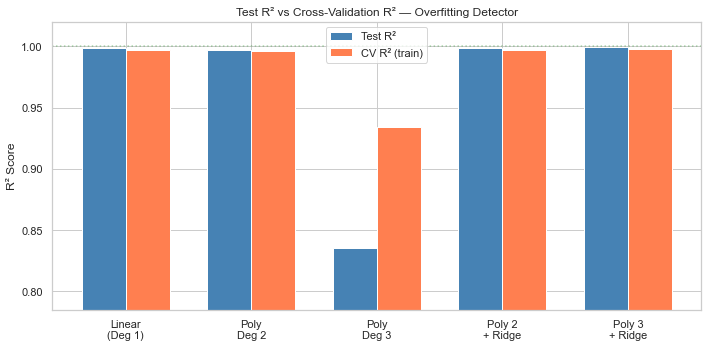

In [20]:
# Visualize: Test R² vs CV R² for each model (overfitting detector)
models = ['Linear\n(Deg 1)', 'Poly\nDeg 2', 'Poly\nDeg 3', 'Poly 2\n+ Ridge', 'Poly 3\n+ Ridge']
test_r2 = [r2_linear, r2_poly2, r2_poly3, r2_poly2r, r2_poly3r]
cv_r2 = [cv_scores_linear.mean(), cv_scores_poly2.mean(), cv_scores_poly3.mean(), cv_poly2r.mean(), cv_poly3r.mean()]

x_pos = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, test_r2, width, label='Test R²', color='steelblue')
bars2 = ax.bar(x_pos + width/2, cv_r2, width, label='CV R² (train)', color='coral')

ax.set_xticks(x_pos)
ax.set_xticklabels(models)
ax.set_ylabel('R² Score')
ax.set_title('Test R² vs Cross-Validation R² — Overfitting Detector')
ax.legend()
ax.set_ylim(min(min(test_r2), min(cv_r2)) - 0.05, 1.02)
ax.axhline(1.0, color='green', linestyle=':', alpha=0.3, label='Perfect')
plt.tight_layout()
plt.show()

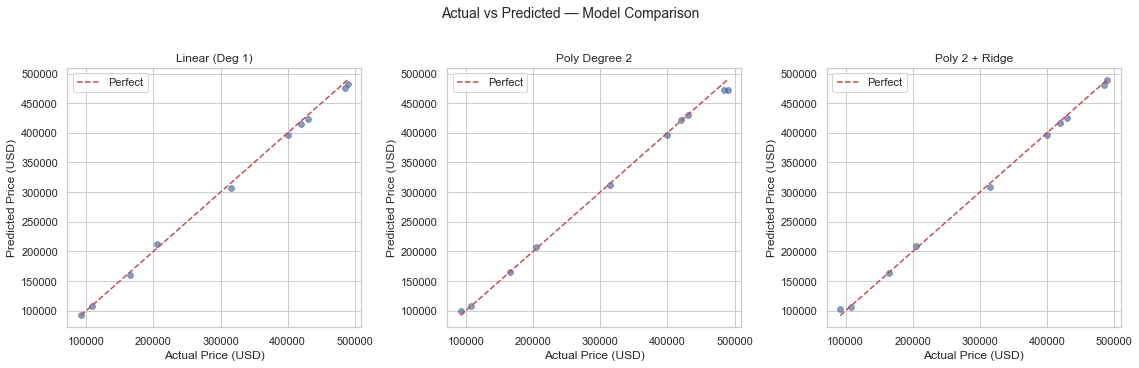

In [21]:
# Actual vs Predicted for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions = [
    ('Linear (Deg 1)', y_pred_linear),
    ('Poly Degree 2', y_pred_poly2),
    ('Poly 2 + Ridge', y_pred_poly2r)
]

for ax, (title, y_p) in zip(axes, predictions):
    ax.scatter(y_test, y_p, alpha=0.7, edgecolors='k', linewidths=0.4)
    min_val = min(y_test.min(), y_p.min())
    max_val = max(y_test.max(), y_p.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect')
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Actual vs Predicted — Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Understanding the Results

### How to read the comparison

| What to look at | Good sign | Bad sign |
|---|---|---|
| **Test R²** | Close to 1.0 | Low or negative |
| **CV R² vs Test R²** | Similar values | Big gap = overfitting |
| **CV R² std** | Small (stable) | Large (unstable model) |
| **Feature count vs samples** | Features << samples | Features > samples ⚠️ |

### Key Observations

1. **Linear (Degree 1)** — Our baseline. Solid performance with only 5 features.

2. **Poly Degree 2** — Adds interaction terms ($x_1 \times x_2$) and squared terms ($x_1^2$). May improve if there are quadratic relationships in the data.

3. **Poly Degree 3** — 55 features from only 40 training samples! This is a classic **overfitting** setup. If test R² drops while train R² stays high, that confirms overfitting.

4. **Poly 2 + Ridge** — Best of both worlds: captures non-linear patterns while Ridge prevents overfitting. Usually the most robust choice.

5. **Poly 3 + Ridge** — Ridge tames the 55-feature explosion, but with so few samples, degree 2 is likely enough.

### When to use Polynomial Features

| Scenario | Recommendation |
|---|---|
| Data has clear curved patterns in scatter plots | ✅ Try degree 2 |
| Large dataset (1000+ samples) | ✅ Can try degree 2 or 3 |
| Small dataset (< 100 samples) | ⚠️ Stick to degree 2 max, use with Ridge/Lasso |
| Already have many features (20+) | ❌ Feature explosion — use interaction_only=True or pick features first |
| Linear model already has R² > 0.99 | 🤔 Probably not needed — diminishing returns |

### Tips

- Always **combine polynomial features with regularization** (Ridge/Lasso) to prevent overfitting
- Use `interaction_only=True` to get only interaction terms ($x_1 x_2$) without powers ($x_1^2$) — reduces feature count
- Compare **CV R²** (not just test R²) to detect overfitting reliably
- Consider using `Pipeline` to keep preprocessing and modeling in one clean workflow